# Structure Input Data

Required:
- `matplotlib`, `cv2`, `numpy`
- `findmaxima2d`
    - https://github.com/dwaithe/MaximaFinder
-  Microsoft Visual C++ with "Microsoft C++ Build Tools"
    - https://visualstudio.microsoft.com/visual-cpp-build-tools/

In [1]:
# imports
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import numpy as np
from skimage.feature import peak_local_max
# from skimage import img_as_float

# from findmaxima2d import find_maxima, find_local_maxima

In [287]:
# 0: channel 640, 1: channel 488, 2 Bright Field, 3: folder name
data = []

dir = os.getcwd()
dir_data = os.getcwd()[:dir.rfind('\\')] + "\\data"
for folder in os.listdir(dir_data):
    new_img = [None, None, None, folder]
    for file in os.listdir(os.path.join(dir_data, folder)):
        if str(file).endswith("colour0.tif"):
            tempImg = mpimg.imread(os.path.join(dir_data, folder, file))
            # new_img[0] = np.array(tempImg)
            new_img[0] = np.array([i[tempImg.shape[1]//2:tempImg.shape[1]] for i in tempImg])
        elif str(file).endswith("colour1.tif"):
            tempImg = mpimg.imread(os.path.join(dir_data, folder, file))
            # new_img[1] = np.array(tempImg)
            new_img[1] = np.array([i[:tempImg.shape[1]//2] for i in tempImg])
        elif str(file).endswith("colour2.tif"):
            tempImg = mpimg.imread(os.path.join(dir_data, folder, file))
            # new_img[2] = np.array(tempImg)
            new_img[2] = np.array([i[:tempImg.shape[1]//2] for i in tempImg])
    data.append(new_img)
data.sort(key = lambda x : int(x[3].split("_")[1]))

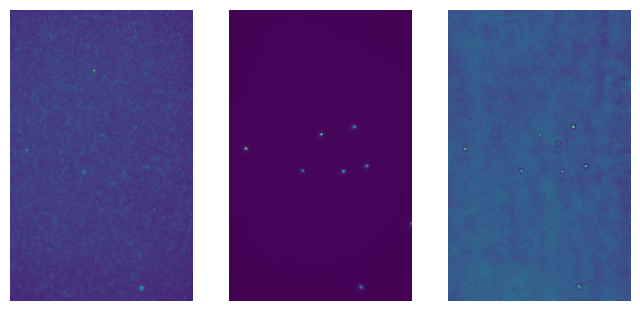

In [290]:
# check image read properly
def printImg(imgs, map=None):
    fig = plt.figure(figsize=(8,15))
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(imgs[i], cmap=map)
        plt.axis('off')
printImg(data[0])

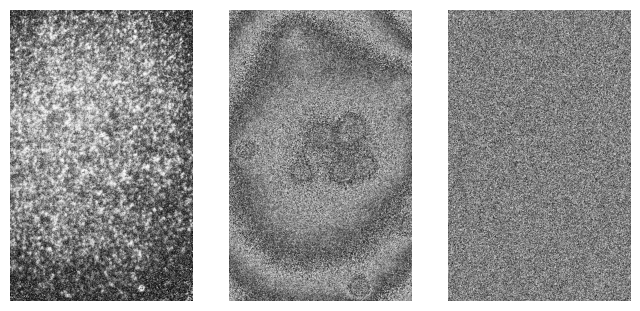

In [93]:
# histogram equalisation
imgsTest = data[0][0:3].copy()
for i in range(len(imgsTest)):
    equ = cv2.equalizeHist(imgsTest[i].astype(np.uint8))
    imgsTest[i] =  equ
printImg(imgsTest, "gray")

1307
575.3652989561131
658.0
65535
2175.234922391649
2975.0
12460
9527.257262119474
9952.0


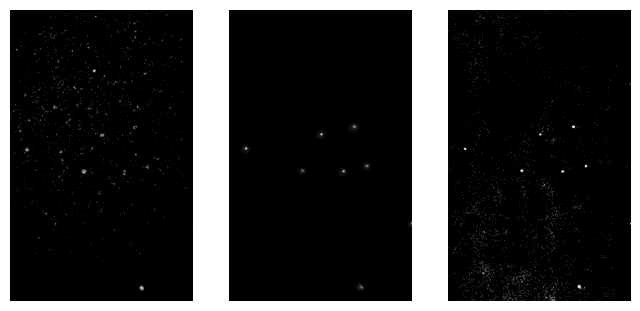

In [271]:
# boundary threshold
data_i = data[0][0:3].copy()
imgsTest = data_i.copy()
for i in range(len(imgsTest)):
    imgsTest_i = imgsTest[i].copy()
    max_i = np.amax(imgsTest_i)
    agv_i = np.mean(imgsTest_i)
    qtl_i = np.percentile(imgsTest_i, 99)
    print(max_i)
    print(agv_i)
    print(qtl_i)
    threshold = qtl_i # 65535
    imgsTest_i[imgsTest_i < threshold] = 0
    # bound = cv2.inRange(imgsTest[i], int(np.amin(imgsTest[i]))-10, int(np.amax(imgsTest[i]))+10)
    imgsTest[i] =  imgsTest_i
printImg(imgsTest, "gray")

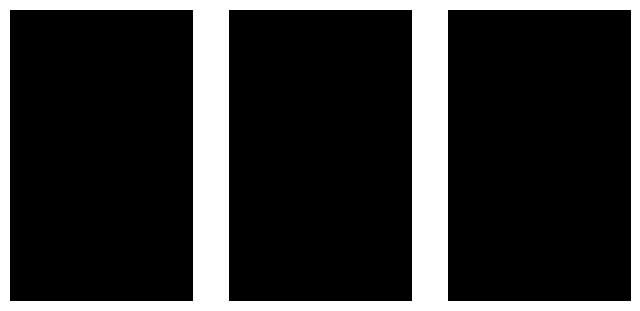

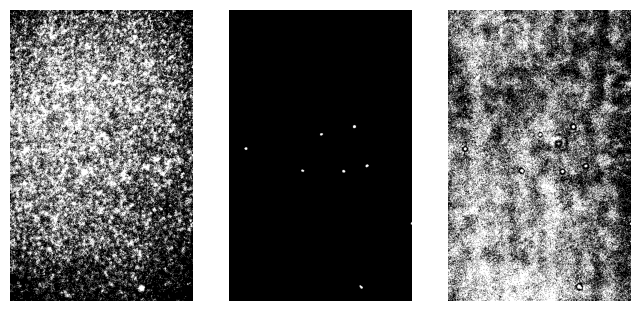

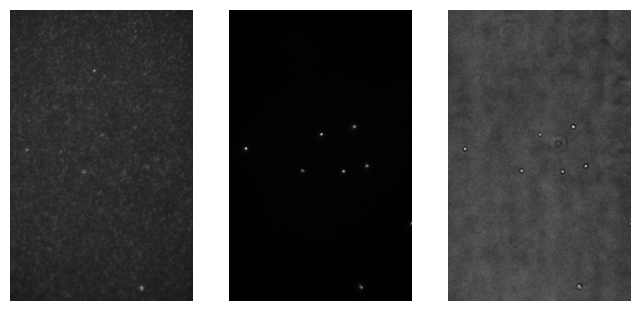

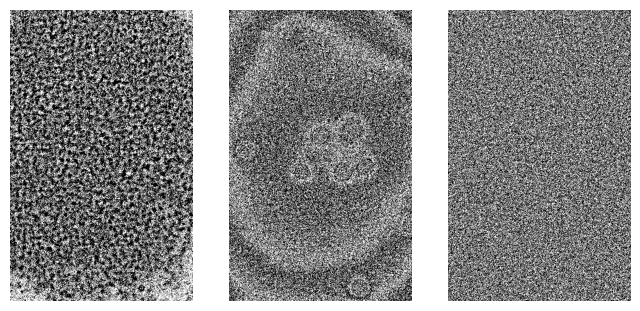

In [254]:
data_i = data[0][0:3].copy()

# binary thresholding
imgsTest = data_i.copy()
for i in range(len(imgsTest)):
    ret1, binary = cv2.threshold(imgsTest[i], 0, 255, cv2.THRESH_BINARY)
    imgsTest[i] =  binary
printImg(imgsTest, "gray")

# Otsu thresholding
imgsTest = data_i.copy()
for i in range(len(imgsTest)):
    ret1, otsu = cv2.threshold(imgsTest[i], 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # print(np.amin(otsu))
    # print(np.amax(otsu))
    imgsTest[i] =  otsu
printImg(imgsTest, "gray")

# Tozero thresholding
imgsTest = data_i.copy()
for i in range(len(imgsTest)):
    ret1, tozero = cv2.threshold(imgsTest[i], 0, 255, cv2.THRESH_TOZERO)
    imgsTest[i] =  tozero
printImg(imgsTest, "gray")

# adaptive thresholding
imgsTest = data_i.copy()
for i in range(len(imgsTest)):
    adapt = cv2.adaptiveThreshold(imgsTest[i].astype(np.uint8), 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 21, 10)
    imgsTest[i] =  adapt
printImg(imgsTest, "gray")


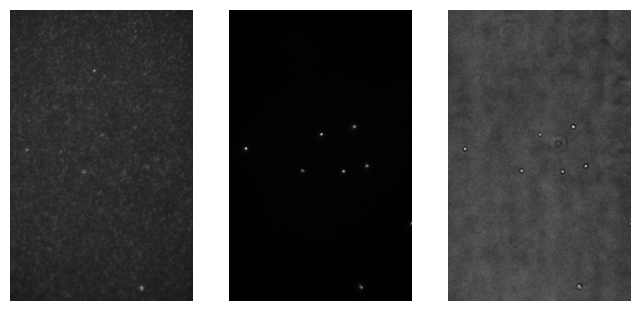

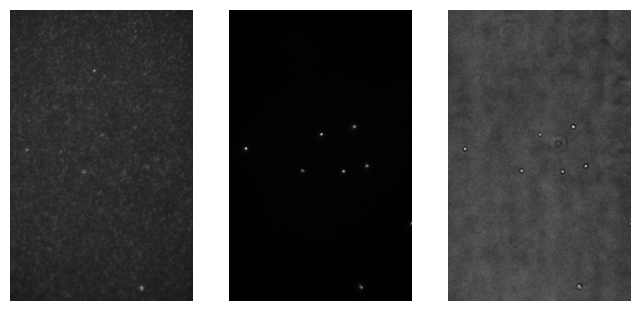

In [95]:
# Tozero thresholding + mask thresholding
printImg(data[0], "gray")
imgsTest = data[0][0:3].copy()
for i in range(len(imgsTest)):
    ret1, tozero = cv2.threshold(imgsTest[i], 127, 65535, cv2.THRESH_TOZERO)
    imgsTest[i] =  tozero
printImg(imgsTest, "gray")

# for i in range(len(imgsTest)):
#     binary_mask = imgsTest[i] < 0.8
#     imgsTest[i] = binary_mask
# printImg(imgsTest[i])

Using sckit-image

https://scikit-image.org/docs/0.23.x/auto_examples/segmentation/plot_peak_local_max.html

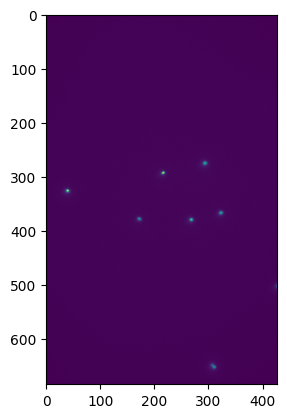

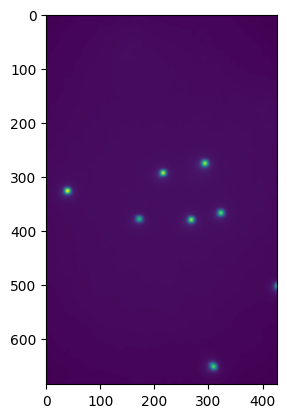

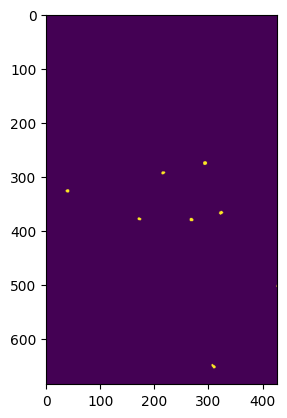

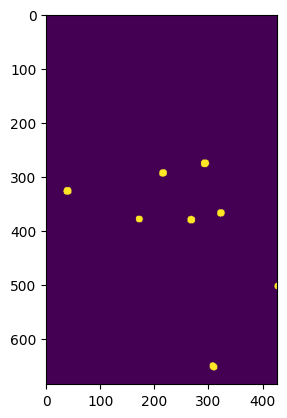

In [156]:
img_peak = data[0][1]
img_peak_blur = cv2.GaussianBlur(img_peak,(13,13), 4)
ret1, img_otsu = cv2.threshold(img_peak, 0, 225, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
ret1, img_blur_otsu = cv2.threshold(img_peak_blur, 0, 225, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.imshow(img_peak)
plt.show()
plt.imshow(img_peak_blur)
plt.show()
plt.imshow(img_otsu)
plt.show()
plt.imshow(img_blur_otsu)
plt.show()

In [159]:
# peaks = peak_local_max(img_peak_blur, min_distance=15, threshold_abs=255)
peaks = peak_local_max(img_otsu, threshold_abs=220)
print(peaks)

[[272 292]
 [272 293]
 [272 294]
 [273 290]
 [273 291]
 [273 292]
 [273 293]
 [273 294]
 [273 295]
 [273 296]
 [274 290]
 [274 291]
 [274 292]
 [274 293]
 [274 294]
 [274 295]
 [274 296]
 [275 290]
 [275 291]
 [275 292]
 [275 293]
 [275 294]
 [275 295]
 [275 296]
 [276 290]
 [276 291]
 [276 292]
 [276 293]
 [276 294]
 [276 295]
 [276 296]
 [277 290]
 [277 291]
 [277 292]
 [277 293]
 [277 294]
 [277 295]
 [277 296]
 [278 291]
 [278 292]
 [278 293]
 [278 294]
 [291 214]
 [291 215]
 [291 216]
 [291 217]
 [291 218]
 [292 213]
 [292 214]
 [292 215]
 [292 216]
 [292 217]
 [292 218]
 [292 219]
 [293 213]
 [293 214]
 [293 215]
 [293 216]
 [293 217]
 [293 218]
 [293 219]
 [294 213]
 [294 214]
 [294 215]
 [294 216]
 [294 217]
 [294 218]
 [295 213]
 [295 214]
 [295 215]
 [295 216]
 [295 217]
 [296 215]
 [324  38]
 [324  39]
 [324  40]
 [324  41]
 [325  37]
 [325  38]
 [325  39]
 [325  40]
 [325  41]
 [325  42]
 [326  36]
 [326  37]
 [326  38]
 [326  39]
 [326  40]
 [326  41]
 [326  42]
 [327  36]

<function matplotlib.pyplot.show(close=None, block=None)>

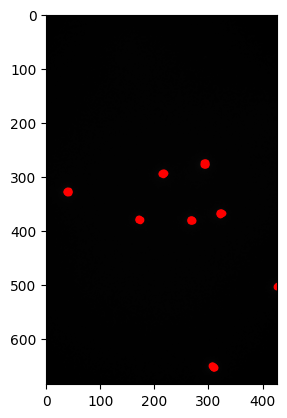

In [160]:
plt.imshow(img_peak, cmap=plt.cm.gray)
plt.plot(peaks[:, 1], peaks[:, 0], 'r.')
plt.show

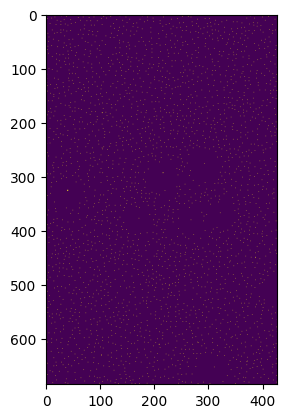

In [143]:
from scipy.ndimage import maximum_filter
import numpy as np

img_peak = data[0][1]
neighborhood = maximum_filter(img_peak, size=10)
peaks_mask = img_peak == neighborhood
ys, xs = np.where(peaks_mask)

plt.imshow(peaks_mask)

In [195]:
print(np.max(data[3][1]))

65535
